# NLP Assignment 4 – Fine-Tuning BERT on IMDB Reviews


## Install Libraries

In [1]:
!pip install transformers datasets torch scikit-learn seaborn -q

## Importing Libraries

In [2]:
import collections
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset, concatenate_datasets
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## Load Dataset

In [3]:
dataset = load_dataset('imdb')
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


## Tokenization

In [4]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(example['text'], padding='max_length', truncation=True, max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column('label', 'labels')
dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

## Balancing Test Set

In [5]:
#since range(1000) gives only negatives as first 1000 are negative
neg = dataset['test'].filter(lambda x: x['labels'] == 0).select(range(500))
pos = dataset['test'].filter(lambda x: x['labels'] == 1).select(range(500))
balanced_test = concatenate_datasets([neg, pos]).shuffle(seed=42)
print('Label distribution:', collections.Counter(balanced_test['labels']))

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Label distribution: Counter({tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(1): 1, tensor(1): 1, tensor(0): 1, tensor(0): 1, tensor(0): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tensor(1): 1, tensor(0): 1, tenso

## Training Arguments

In [6]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy='epoch',
    save_strategy='no',
    report_to='none'
)

---
## Experiment 1 – Freeze ALL BERT Layers -Clasifier Head Only

In [7]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

#freeze all BERT encoder weights
for param in model.bert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 1,538 / 109,483,778 (0.0%)


In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'].shuffle(seed=42).select(range(5000)),
    eval_dataset=balanced_test,
)
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.694807,0.685737
2,0.685493,0.679537
3,0.685047,0.678500


TrainOutput(global_step=1875, training_loss=0.6873111328125, metrics={'train_runtime': 160.6968, 'train_samples_per_second': 93.343, 'train_steps_per_second': 11.668, 'total_flos': 986666457600000.0, 'train_loss': 0.6873111328125, 'epoch': 3.0})

### Evaluation – Experiment 1

Label distribution: Counter({1: 500, 0: 500})
Accuracy : 0.579
Precision: 0.5501905972045743
Recall   : 0.866
F1 Score : 0.6728826728826729


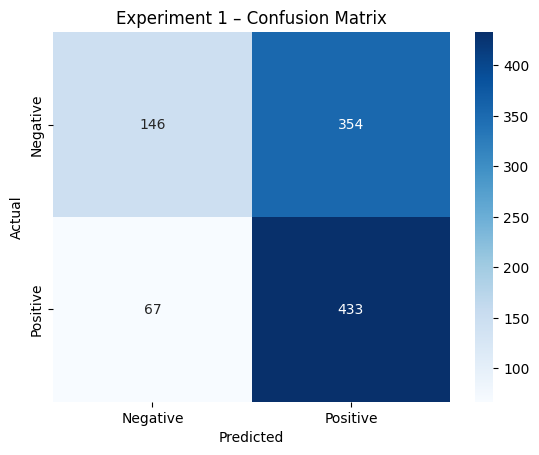

              precision    recall  f1-score   support

    Negative       0.69      0.29      0.41       500
    Positive       0.55      0.87      0.67       500

    accuracy                           0.58      1000
   macro avg       0.62      0.58      0.54      1000
weighted avg       0.62      0.58      0.54      1000



In [9]:
predictions = trainer.predict(balanced_test)
preds  = predictions.predictions.argmax(axis=1)
labels = predictions.label_ids

print('Label distribution:', collections.Counter(labels.tolist()))
print('Accuracy :', accuracy_score(labels, preds))
print('Precision:', precision_score(labels, preds, zero_division=0))
print('Recall   :', recall_score(labels, preds, zero_division=0))
print('F1 Score :', f1_score(labels, preds, zero_division=0))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Experiment 1 – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(labels, preds, target_names=['Negative','Positive']))

---
## Experiment 2 – Fine-Tuning Last 2 BERT Layers + Classifier

In [10]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

#freeze all BERT layers
for param in model.bert.parameters():
    param.requires_grad = False

#unfreeze last 2 encoder layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 14,177,282 / 109,483,778 (12.9%)


In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'].shuffle(seed=42).select(range(5000)),
    eval_dataset=balanced_test,
)
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.508185,0.386346
2,0.365696,0.372229
3,0.335741,0.358979


TrainOutput(global_step=1875, training_loss=0.3875936319986979, metrics={'train_runtime': 212.7587, 'train_samples_per_second': 70.502, 'train_steps_per_second': 8.813, 'total_flos': 986666457600000.0, 'train_loss': 0.3875936319986979, 'epoch': 3.0})

### Evaluation – Experiment 2

Label distribution: Counter({1: 500, 0: 500})
Accuracy : 0.849
Precision: 0.8166969147005445
Recall   : 0.9
F1 Score : 0.8563273073263559


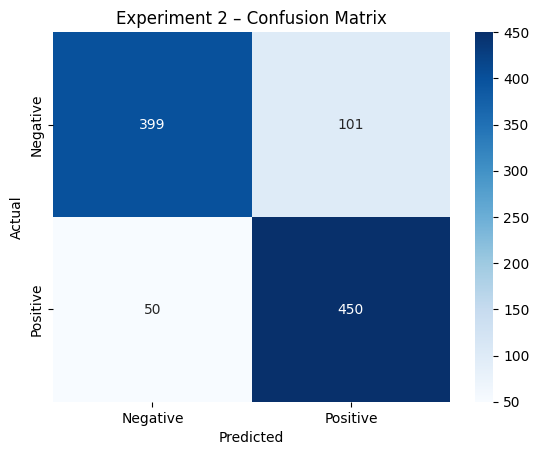

              precision    recall  f1-score   support

    Negative       0.89      0.80      0.84       500
    Positive       0.82      0.90      0.86       500

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



In [12]:
predictions = trainer.predict(balanced_test)
preds  = predictions.predictions.argmax(axis=1)
labels = predictions.label_ids

print('Label distribution:', collections.Counter(labels.tolist()))
print('Accuracy :', accuracy_score(labels, preds))
print('Precision:', precision_score(labels, preds, zero_division=0))
print('Recall   :', recall_score(labels, preds, zero_division=0))
print('F1 Score :', f1_score(labels, preds, zero_division=0))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Experiment 2 – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(labels, preds, target_names=['Negative','Positive']))

---
## Experiment 3 -Bonus – DistilBERT

In [13]:
distil_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

distil_dataset = load_dataset('imdb')

def tokenize_distil(example):
    return distil_tokenizer(example['text'], padding='max_length', truncation=True, max_length=128)

distil_dataset = distil_dataset.map(tokenize_distil, batched=True)
distil_dataset = distil_dataset.rename_column('label', 'labels')
distil_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

d_neg = distil_dataset['test'].filter(lambda x: x['labels'] == 0).select(range(500))
d_pos = distil_dataset['test'].filter(lambda x: x['labels'] == 1).select(range(500))
distil_balanced_test = concatenate_datasets([d_neg, d_pos]).shuffle(seed=42)

model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
print('DistilBERT ready.')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT ready.


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=distil_dataset['train'].shuffle(seed=42).select(range(5000)),
    eval_dataset=distil_balanced_test,
)
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.450162,0.395218
2,0.308501,0.437746
3,0.223874,0.524736


TrainOutput(global_step=1875, training_loss=0.29704979654947916, metrics={'train_runtime': 240.3436, 'train_samples_per_second': 62.411, 'train_steps_per_second': 7.801, 'total_flos': 496752744960000.0, 'train_loss': 0.29704979654947916, 'epoch': 3.0})

### Evaluation – Experiment 3

Label distribution: Counter({1: 500, 0: 500})
Accuracy : 0.859
Precision: 0.8199643493761141
Recall   : 0.92
F1 Score : 0.8671065032987747


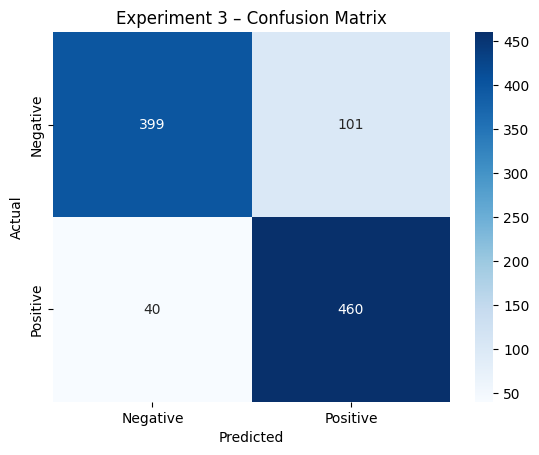

              precision    recall  f1-score   support

    Negative       0.91      0.80      0.85       500
    Positive       0.82      0.92      0.87       500

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



In [15]:
predictions = trainer.predict(distil_balanced_test)
preds  = predictions.predictions.argmax(axis=1)
labels = predictions.label_ids

print('Label distribution:', collections.Counter(labels.tolist()))
print('Accuracy :', accuracy_score(labels, preds))
print('Precision:', precision_score(labels, preds, zero_division=0))
print('Recall   :', recall_score(labels, preds, zero_division=0))
print('F1 Score :', f1_score(labels, preds, zero_division=0))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Experiment 3 – Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(labels, preds, target_names=['Negative','Positive']))

---
## Results Comparison

                           Accuracy  Precision  Recall        F1
Experiment                                                      
Exp 1: Frozen BERT            0.579   0.550191   0.866  0.672883
Exp 2: Last 2 Layers          0.849   0.816697   0.900  0.856327
Exp 3: DistilBERT (Bonus)     0.859   0.819964   0.920  0.867107


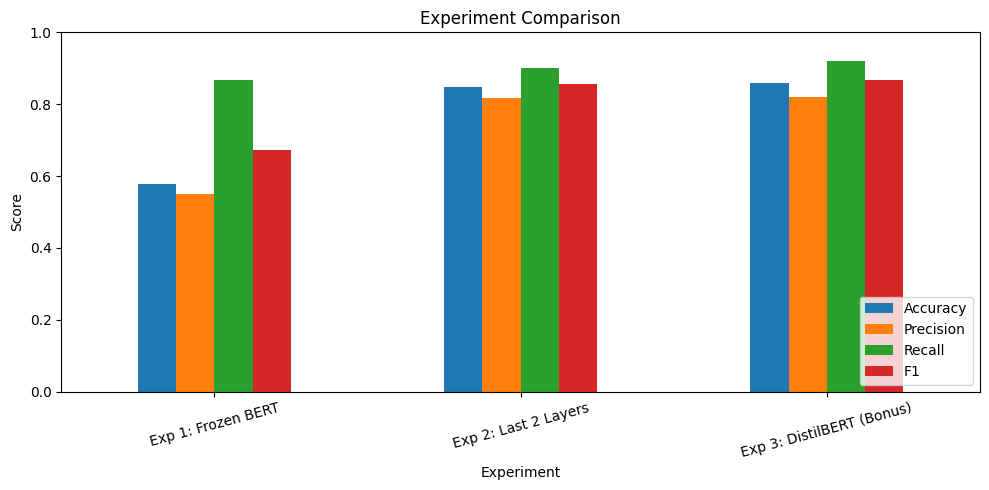

In [17]:
import pandas as pd
# values updated with actual results after running all experiments
results = pd.DataFrame([
    {'Experiment': 'Exp 1: Frozen BERT','Accuracy':  0.579, 'Precision': 0.5501905972045743, 'Recall': 0.866, 'F1': 0.6728826728826729},
    {'Experiment': 'Exp 2: Last 2 Layers','Accuracy': 0.849, 'Precision': 0.8166969147005445, 'Recall': 0.9, 'F1': 0.8563273073263559},
    {'Experiment': 'Exp 3: DistilBERT (Bonus)','Accuracy': 0.859, 'Precision': 0.8199643493761141, 'Recall': 0.92, 'F1': 0.8671065032987747},
]).set_index('Experiment')

print(results.to_string())

results.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15)
plt.title('Experiment Comparison')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Analysis & Insights

- **Exp 1 (Frozen BERT):** Fastest to train. Only the classifier head is updated. BERT's pre-trained representations are already strong for sentiment, giving a decent baseline.
- **Exp 2 (Last 2 Layers):** Allows the top encoder layers to adapt to sentiment. Usually gives 2–5% better accuracy than Exp 1 since the model can specialise.
- **Exp 3 (DistilBERT):** 40% smaller and faster than BERT. Achieves similar accuracy at lower compute cost — best choice for deployment.

In [19]:
#Clear widget metadata before downloading
import IPython
IPython.display.clear_output()